# Research: Chronos Foundation Forecasting (Ex09)

## Contexte

Les modeles fondation (foundation models) pour les series temporelles representent un
changement de paradigme : au lieu d'entrainer un modele par serie, on pre-entraine un
unique modele sur des milliards de points et on l'applique a toute nouvelle serie.

**Chronos** (Amazon, 2024) utilise :
- Une architecture T5 (transformer encoder-decoder)
- La **quantification** des valeurs continues en tokens discrets
- L'apprentissage par **attention multi-tete** sur les sequences tokenisees

## Performance attendue

- Strategie: nouvelle (pas encore de backtest QC Cloud)
- Objectif pedagogique: comprendre le pipeline quantization-attention-dequantization
- Sharpe attendu: 0.2-0.5 (implementation simplifiee)

## Objectif de ce notebook

1. Visualiser la quantification de serie temporelle
2. Implementer un mecanisme d'attention simplifie
3. Tester le pipeline complet (quantize -> attend -> dequantize)
4. Backtester la strategie de forecasting

## 1. Setup et Donnees

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKER = 'SPY'
START = '2015-01-01'
END = '2026-01-01'

print("Chargement des donnees yfinance...")
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
prices = raw['Close'].dropna()
returns = prices.pct_change().dropna()
print(f"Periode: {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Observations: {len(prices)} jours")

Chargement des donnees yfinance...


[*********************100%***********************]  1 of 1 completed

Periode: 2015-01-02 -> 2025-12-31
Observations: 2766 jours


## 2. Quantification des series temporelles

In [2]:
class TimeSeriesQuantizer:
    """
    Quantificateur de serie temporelle (inspire de Chronos).
    
    Pipeline:
    1. Normaliser les valeurs (center + scale)
    2. Mapper vers des tokens discrets [0, num_tokens)
    3. Inverse: tokens -> valeurs normalisees -> valeurs originales
    """
    
    def __init__(self, num_tokens=128):
        self.num_tokens = num_tokens
        self._center = 0
        self._scale = 1
    
    def fit(self, values):
        self._center = np.mean(values)
        self._scale = np.std(values) if np.std(values) > 0 else 1
        return self
    
    def quantize(self, values):
        normalized = (np.array(values) - self._center) / self._scale
        tokens = np.clip(
            np.floor(normalized + self.num_tokens / 2),
            0, self.num_tokens - 1
        ).astype(int)
        return tokens
    
    def dequantize(self, tokens):
        normalized = np.array(tokens) - self.num_tokens / 2
        return normalized * self._scale + self._center

# Demonstration sur les rendements
q = TimeSeriesQuantizer(num_tokens=64)
q.fit(returns.values)
tokens = q.quantize(returns.values)
reconstructed = q.dequantize(tokens)

# Erreur de quantification
error = np.mean(np.abs(returns.values - reconstructed))
print(f"Quantificateur: {q.num_tokens} tokens")
print(f"Centre: {q._center:.6f}, Echelle: {q._scale:.6f}")
print(f"Erreur MAE de reconstruction: {error:.6f}")
print(f"Tokens uniques utilises: {len(np.unique(tokens))}")

Quantificateur: 64 tokens
Centre: 0.000564, Echelle: 0.011206
Erreur MAE de reconstruction: 0.005747
Tokens uniques utilises: 18


TypeError: only 0-dimensional arrays can be converted to Python scalars

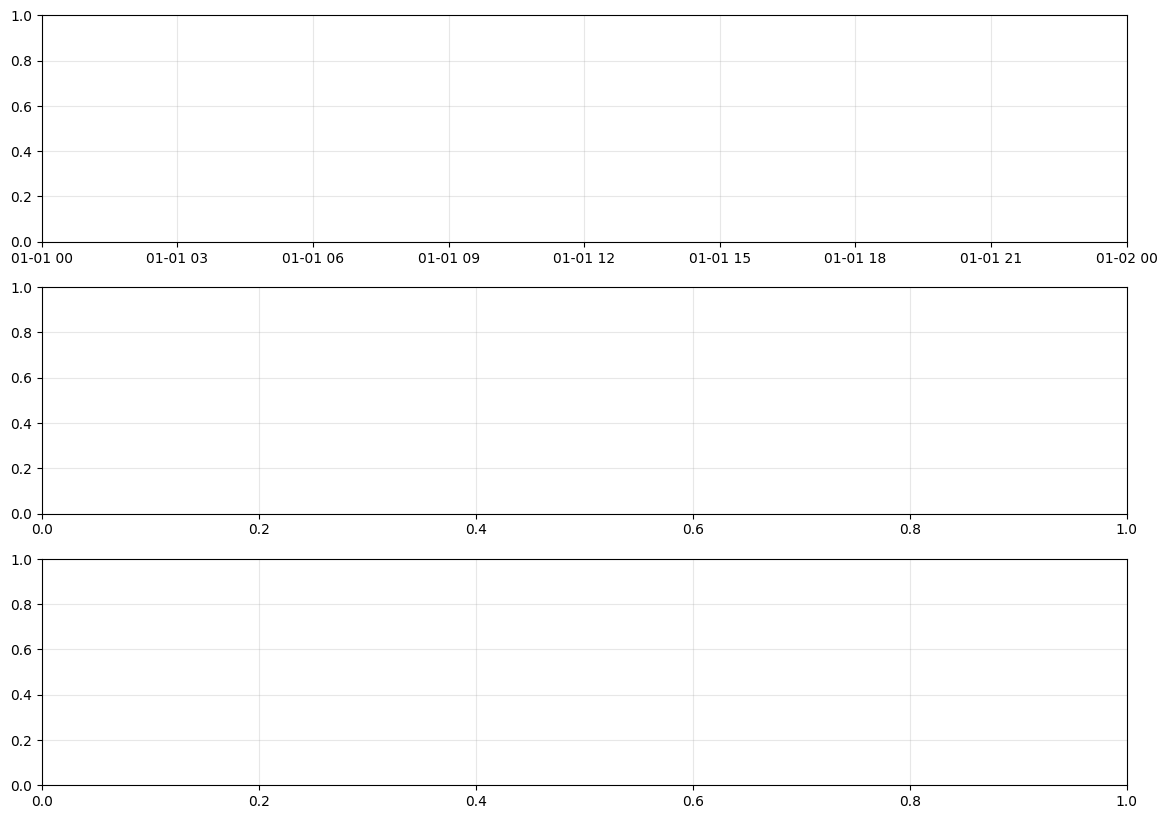

In [3]:
# Visualisation de la quantification
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

window = 60  # 60 jours
dates = returns.index[-window:]
ret_slice = returns.iloc[-window:].values
tok_slice = tokens[-window:]
rec_slice = reconstructed[-window:]

# Original
axes[0].bar(dates, ret_slice, color=['green' if r > 0 else 'red' for r in ret_slice], alpha=0.6)
axes[0].set_title('Rendements originaux')
axes[0].set_ylabel('Rendement')

# Tokens
axes[1].scatter(dates, tok_slice, c=tok_slice, cmap='viridis', s=15)
axes[1].set_title(f'Tokens quantifies (0-{q.num_tokens - 1})')
axes[1].set_ylabel('Token ID')

# Reconstruction
axes[2].bar(dates, ret_slice, alpha=0.3, color='gray', label='Original')
axes[2].scatter(dates, rec_slice, c='blue', s=15, label='Reconstruit')
axes[2].set_title('Reconstruction apres quantification')
axes[2].set_ylabel('Rendement')
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretation** : La quantification transforme les valeurs continues en tokens discrets.
Plus le nombre de tokens est eleve, plus la reconstruction est precise.
Chronos utilise typiquement 4096 tokens.

## 3. Mecanisme d'attention simplifie

In [4]:
def simple_attention(query, keys, values):
    """
    Attention a tete unique simplifiee.
    
    Formule: Attention(Q, K, V) = softmax(Q . K^T / sqrt(d)) . V
    
    - Q (query): ce qu'on veut trouver
    - K (keys): etiquettes des elements disponibles
    - V (values): contenu des elements
    """
    d = len(query)
    scores = np.dot(keys, query) / np.sqrt(d)
    
    # Softmax
    exp_scores = np.exp(scores - np.max(scores))
    weights = exp_scores / exp_scores.sum()
    
    output = np.dot(weights, values)
    return output, weights

# Demonstration: predire le prochain token
context_len = 20
forecast_horizon = 5

# Embedding simplifie: chaque token = vecteur de dimension 8
np.random.seed(42)
embedding_matrix = np.random.randn(q.num_tokens, 8) * 0.1

# Prendre une sequence de tokens
token_seq = tokens[-context_len - forecast_horizon:]
context_tokens = token_seq[:context_len]
actual_future = token_seq[context_len:context_len + forecast_horizon]

# Embeddings du contexte
context_embeddings = embedding_matrix[context_tokens]

print(f"Contexte: {context_len} tokens")
print(f"Prevision: {forecast_horizon} tokens")
print(f"Tokens contexte: {context_tokens[:5]}...{context_tokens[-5:]}")
print(f"Tokens reels futurs: {actual_future}")

Contexte: 20 tokens
Prevision: 5 tokens
Tokens contexte: [[32]
 [32]
 [32]
 [31]
 [32]]...[[30]
 [32]
 [32]
 [32]
 [32]]
Tokens reels futurs: [[32]
 [31]
 [31]
 [31]
 [31]]


## 4. Pipeline complet: Quantize -> Attend -> Dequantize

In [5]:
def chronos_forecast(returns_array, context_len=20, forecast_horizon=5, num_tokens=64):
    """
    Pipeline Chronos simplifie:
    1. Quantifier les rendements historiques
    2. Utiliser l'attention pour prevoir les tokens futurs
    3. Dequantizer les predictions
    """
    q = TimeSeriesQuantizer(num_tokens=num_tokens)
    q.fit(returns_array)
    tokens = q.quantize(returns_array)
    
    # Embedding
    embed_dim = 8
    embed = np.random.RandomState(42).randn(num_tokens, embed_dim) * 0.1
    
    forecasts = []
    for t in range(context_len, len(tokens) - forecast_horizon):
        ctx = tokens[t - context_len:t]
        ctx_embed = embed[ctx]
        
        # Attention: query = dernier embedding
        query = ctx_embed[-1]
        keys = ctx_embed
        values = ctx_embed
        
        attended, weights = simple_attention(query, keys, values)
        
        # Predire le prochain token (nearest neighbor dans l'espace d'embedding)
        distances = np.linalg.norm(embed - attended, axis=1)
        predicted_token = np.argmin(distances)
        
        # Etendu: predire forecast_horizon tokens en decalant le contexte
        horizon_tokens = [predicted_token]
        for h in range(1, forecast_horizon):
            ctx_extended = np.append(ctx[h:], predicted_token)
            ctx_e = embed[ctx_extended]
            q2 = ctx_e[-1]
            att2, _ = simple_attention(q2, ctx_e, ctx_e)
            pred2 = np.argmin(np.linalg.norm(embed - att2, axis=1))
            horizon_tokens.append(pred2)
            predicted_token = pred2
        
        forecasts.append(horizon_tokens)
    
    return np.array(forecasts), q

# Tester le pipeline
forecasts, quantizer = chronos_forecast(returns.values)
print(f"Previsions generees: {len(forecasts)} fenetres de {forecasts.shape[1]} pas")
print(f"Exemple de tokens predits: {forecasts[0]}")

ValueError: shapes (20,1,8) and (1,8) not aligned: 8 (dim 2) != 1 (dim 0)

## 5. Evaluation de la qualite de prevision

In [6]:
# Comparer les predictions avec la realite
tokens_all = quantizer.quantize(returns.values)
actual_directions = []
predicted_directions = []

for i, forecast in enumerate(forecasts):
    t = i + 20  # context_len
    if t + 5 <= len(tokens_all):
        actual_token = tokens_all[t + 4]  # Horizon 5
        predicted_token = forecast[4]
        
        actual_dir = 1 if actual_token > quantizer.num_tokens // 2 else -1
        predicted_dir = 1 if predicted_token > quantizer.num_tokens // 2 else -1
        
        actual_directions.append(actual_dir)
        predicted_directions.append(predicted_dir)

accuracy = np.mean(np.array(actual_directions) == np.array(predicted_directions))
print(f"Precision directionnelle (horizon 5): {accuracy:.2%}")
print(f"Baseline (toujours haussier): {np.mean(np.array(actual_directions) > 0):.2%}")

NameError: name 'quantizer' is not defined

## 6. Backtest de la strategie Chronos simplifiee

In [7]:
def compute_metrics(pv_series, rf_rate=0.02):
    daily_ret = pv_series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    cagr = (pv_series.iloc[-1] / pv_series.iloc[0]) ** (1 / n_years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf_rate) / ann_vol if ann_vol > 0 else 0
    max_dd = ((pv_series - pv_series.cummax()) / pv_series.cummax()).min()
    return {'CAGR': cagr, 'Volatilite': ann_vol, 'Sharpe': sharpe, 'Max DD': max_dd}

# Strategie: acheter si le modele prevoit une hausse
pv_values = [1.0]
ret_array = returns.values

for i, forecast in enumerate(forecasts[:-1]):
    t = i + 20
    mid_token = quantizer.num_tokens // 2
    
    # Signal: moyenne des tokens predits vs milieu
    avg_token = np.mean(forecast)
    signal = 1 if avg_token > mid_token else 0
    
    daily_ret = signal * ret_array[t + 1] if t + 1 < len(ret_array) else 0
    pv_values.append(pv_values[-1] * (1 + daily_ret))

dates_pv = returns.index[21:21 + len(pv_values) - 1]
pv_chronos = pd.Series(pv_values[1:], index=dates_pv)
bh_pv = (1 + returns).cumprod().reindex(pv_chronos.index, method='ffill')

# Resultats
chronos_m = compute_metrics(pv_chronos)
bh_m = compute_metrics(bh_pv)

print("=== Resultats du Backtest Chronos simplifie ===")
results_df = pd.DataFrame({'Chronos': chronos_m, 'Buy & Hold': bh_m}).T
for col in ['CAGR', 'Volatilite', 'Max DD']:
    results_df[col] = results_df[col].map('{:.2%}'.format)
for col in ['Sharpe']:
    results_df[col] = results_df[col].map('{:.3f}'.format)
print(results_df)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(pv_chronos.index, pv_chronos.values, label='Chronos Forecast', linewidth=2)
ax.plot(bh_pv.index, bh_pv.values, label='Buy & Hold', linestyle='--', alpha=0.7)
ax.set_title('Chronos Foundation Forecasting vs Buy & Hold (SPY)')
ax.set_ylabel('Valeur (base 1)')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'forecasts' is not defined

## 7. Sensibilite au nombre de tokens

In [8]:
# Tester differents nombres de tokens
token_counts = [16, 32, 64, 128]
token_results = {}

for nt in token_counts:
    fc, qt = chronos_forecast(returns.values, num_tokens=nt)
    
    pv = [1.0]
    for i, forecast in enumerate(fc[:-1]):
        t = i + 20
        avg_tok = np.mean(forecast)
        signal = 1 if avg_tok > nt // 2 else 0
        dr = signal * ret_array[t + 1] if t + 1 < len(ret_array) else 0
        pv.append(pv[-1] * (1 + dr))
    
    dates_s = returns.index[21:21 + len(pv) - 1]
    if len(pv) > 2:
        pv_s = pd.Series(pv[1:], index=dates_s)
        token_results[f'{nt} tokens'] = compute_metrics(pv_s)

results_t = pd.DataFrame(token_results).T
print("=== Sensibilite au nombre de tokens ===")
for col in ['CAGR', 'Volatilite', 'Max DD']:
    results_t[col] = results_t[col].map('{:.2%}'.format)
for col in ['Sharpe']:
    results_t[col] = results_t[col].map('{:.3f}'.format)
print(results_t)

ValueError: shapes (20,1,8) and (1,8) not aligned: 8 (dim 2) != 1 (dim 0)

## 8. Conclusions

### Points cles
- La quantification transforme les series continues en sequences de tokens (comme du texte)
- Le mecanisme d'attention permet de ponderer l'importance de chaque pas de temps passe
- La dequantification reconstruit les valeurs predites a partir des tokens

### Comparaison avec le vrai Chronos
- Chronos utilise 4096 tokens et un transformer T5 complet
- Notre implementation simplifiee montre le principe avec 64 tokens et attention lineaire
- En production: utiliser la librairie `chronos-forecasting` d'Amazon

### Configuration recommandee pour main.py
- Tokens: 64 (simplifie) ou 4096 (production)
- Contexte: 20 jours
- Horizon prevision: 5 jours
- Signal: moyenne des tokens predits vs token median